In [2]:
import numpy as np
import pandas as pd

# Make results reproducible
np.random.seed(7911)

n_policies = 10000

In [20]:
portfolio = pd.DataFrame({
    "policy_id": np.arange(1, n_policies + 1),

    "issue_age": np.random.randint(20, 71, n_policies),

    "gender": np.random.choice(
        ["Male", "Female"],
        n_policies,
        p=[0.52, 0.48]
    ),

    "policy_duration": np.random.randint(1, 31, n_policies)
})

In [21]:
portfolio["attained_age"] = (
    portfolio["issue_age"] + portfolio["policy_duration"]
)

In [15]:

portfolio.describe()

,policy_id,issue_age,policy_duration,attained_age
count,10000.00000,10000.00000,10000.000000,10000.000000
mean,5000.50000,45.19820,15.535400,60.733600
std,2886.89568,14.76564,8.661954,16.915107
min,1.00000,20.00000,1.000000,21.000000
25%,2500.75000,33.00000,8.000000,48.000000
50%,5000.50000,45.00000,16.000000,61.000000
75%,7500.25000,58.00000,23.000000,74.000000
max,10000.00000,70.00000,30.000000,100.000000


In [ ]:


portfolio["gender"].value_counts()

gender
Male      5254
Female    4746
Name: count, dtype: int64

<Axes: >

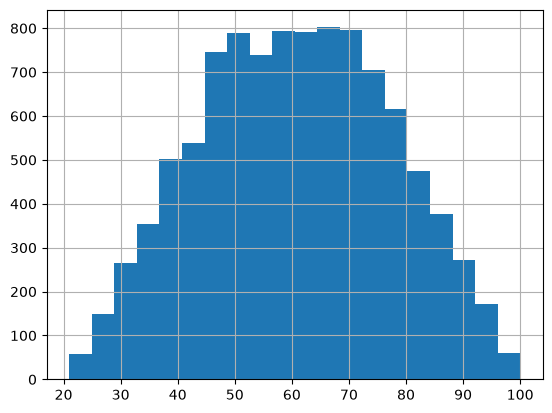

In [ ]:


portfolio["attained_age"].hist(bins=20)

In [5]:
portfolio.groupby("gender")["attained_age"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,4746.0,60.465445,16.850091,21.0,48.0,61.0,73.0,100.0
Male,5254.0,60.975828,16.971583,21.0,48.0,61.0,74.0,100.0


In [6]:
life_table_f = pd.read_excel("../data/raw/PerLifeTables_F_Hist_TR2023.xlsx", skiprows = 4)
life_table_m = pd.read_excel("../data/raw/PerLifeTables_M_Hist_TR2023.xlsx",skiprows = 4)

In [17]:
life_table_f.head(10)

,Year,x,q(x),l(x),d(x),L(x),T(x),e(x),D(x),M(x),A(x),N(x),a(x),12a(x)
0,1900,0,0.119694,100000,11969,92047,4895712,48.96,100000,41416,0.4142,2605699,26.0570,307.18
1,1900,1,0.036172,88031,3184,86438,4803665,54.57,86051,29716,0.3453,2505699,29.1186,343.92
2,1900,2,0.017817,84846,1512,84090,4717227,55.60,81074,26673,0.3290,2419648,29.8449,352.64
3,1900,3,0.012920,83335,1077,82796,4633136,55.60,77839,25261,0.3245,2338574,30.0436,355.02
4,1900,4,0.010306,82258,848,81834,4550340,55.32,75106,24278,0.3233,2260734,30.1005,355.71
5,1900,5,0.007609,81410,619,81100,4468506,54.89,72661,23522,0.3237,2185628,30.0799,355.46
6,1900,6,0.005501,80791,444,80568,4387405,54.31,70487,22981,0.3260,2112967,29.9768,354.22
7,1900,7,0.003987,80346,320,80186,4306837,53.60,68523,22602,0.3298,2042481,29.8072,352.19
8,1900,8,0.003058,80026,245,79904,4226651,52.82,66715,22335,0.3348,1973958,29.5878,349.55
9,1900,9,0.002649,79781,211,79676,4146747,51.98,65016,22136,0.3405,1907242,29.3350,346.52


In [18]:
life_table_f.columns

Index(['Year', 'x', 'q(x)', 'l(x)', 'd(x)', 'L(x)', 'T(x)', 'e(x)', 'D(x)',
       'M(x)', 'A(x)', 'N(x)', 'a(x)', '12a(x)'],
      dtype='str')

In [22]:
# Cleaning the table
female_2020 = life_table_f[life_table_f["Year"] == 2020].copy()
male_2020 = life_table_m[life_table_m["Year"] == 2020].copy()

female_2020 = female_2020[["x", "q(x)"]]
male_2020 = male_2020[["x", "q(x)"]]

female_2020 = female_2020.rename(columns={
    "x": "attained_age",
    "q(x)": "qx"
})

male_2020 = male_2020.rename(columns={
    "x": "attained_age",
    "q(x)": "qx"
})

female_2020["gender"] = "Female"
male_2020["gender"] = "Male"

life_table = pd.concat(
    [female_2020, male_2020],
    ignore_index=True
)

portfolio = portfolio.merge(
    life_table,
    on=["gender", "attained_age"],
    how="left"
)

portfolio["expected_deaths"] = portfolio["qx"]

In [23]:
portfolio.head()

,policy_id,issue_age,gender,policy_duration,attained_age,qx,expected_deaths
0,1,67,Male,11,78,0.054265,0.054265
1,2,35,Female,23,58,0.006752,0.006752
2,3,52,Female,24,76,0.030631,0.030631
3,4,34,Female,2,36,0.001386,0.001386
4,5,59,Female,15,74,0.025030,0.025030


In [10]:
portfolio["qx"].describe()

count    10000.000000
mean         0.030724
std          0.052591
min          0.000533
25%          0.003911
50%          0.011265
75%          0.030438
max          0.384967
Name: qx, dtype: float64

In [24]:
portfolio.sort_values("qx", ascending=False).head(10)

,policy_id,issue_age,gender,policy_duration,attained_age,qx,expected_deaths
4455,4456,70,Male,30,100,0.384967,0.384967
9056,9057,70,Male,30,100,0.384967,0.384967
6300,6301,69,Male,30,99,0.366635,0.366635
3832,3833,69,Male,30,99,0.366635,0.366635
1023,1024,70,Male,29,99,0.366635,0.366635
2650,2651,70,Male,29,99,0.366635,0.366635
383,384,70,Male,29,99,0.366635,0.366635
6053,6054,69,Male,30,99,0.366635,0.366635
898,899,68,Male,30,98,0.349177,0.349177
8850,8851,68,Male,30,98,0.349177,0.349177


In [25]:
portfolio["death"] = np.random.binomial(
    n=1,
    p=portfolio["qx"]
)

In [26]:
portfolio["death"].sum()


np.int64(328)

In [27]:
portfolio["qx"].sum()

np.float64(307.145317)

In [28]:
ae_ratio = portfolio["death"].sum() / portfolio["qx"].sum()